# Analiza ljubljanskega nepremičninskega trga
Seminarska naloga pri predmetu Uvod v programiranje.

V tej nalogi analiziramo podatke o nepremičninah v Ljubljani. Cilj je ugotoviti povprečne cene po mestnih četrteh, porazdelitev stanovanj po številu sob in vpliv starosti stavbe na ceno kvadratnega metra.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Naložimo podatke iz CSV datoteke
df = pd.read_csv("podatki/nepremicnine.csv")

# Izpišemo osnovne informacije, da preverimo, če se je vse pravilno naložilo
print(f"Skupno število vseh oglasov v začetni bazi: {len(df)}")
df.head(3)

Skupno število vseh oglasov v začetni bazi: 250


,id,naslov,lokacija,stevilo_sob,cena,velikost_m2,leto_gradnje,cena_per_m2
0,7451368,LJ. ŠIŠKA,Šiška,Garsonjera,182000.0,25.0,1966,7280.00
1,7450882,"RUDNIK, JURČKOVA",Rudnik,5-sobno,689000.0,104.0,2005,6625.00
2,7450913,ZUPANČIČEVA JAMA,Zupančičeva Jama,1-sobno,325000.0,48.0,1995,6770.83


## Čiščenje in predobdelava podatkov
V tem koraku definiramo funkcijo, ki surove in razpršene lokacije v oglasih združi v večje, pregledne ljubljanske mestne četrti. Prav tako pretvorimo tekstovne podatke v števila in izločimo oglase z neveljavnimi cenami (npr. cene enake 0 ali napake pri zajemu).

In [ ]:
# 1. Funkcija za združevanje lokacij v mestne četrti
def zdruzi_v_skupine(lokacija):
    if not isinstance(lokacija, str):
        return None
    
    l = lokacija.strip()
    
    if l in ["Center", "Stara Lj.", "Tabor", "Prule", "Kodeljevo"]:
        return "Center Ljubljana"
    elif l in ["Bežigrad", "Zupančičeva Jama", "BS 3", "Brinje"]:
        return "Bežigrad"
    elif l in ["Savsko Naselje", "Nove Jarše", "Zelena Jama", "Stožice"]:
        return "Savsko naselje – Jarše"
    elif l in ["Moste", "Štepanjsko Naselje"]:
        return "Moste"
    elif l in ["Šiška", "Zg. Šiška", "Sp. Šiška"]:
        return "Šiška"
    elif l in ["Koseze", "Dravlje", "Podutik"]:
        return "Koseze – Dravlje"
    elif l in ["Šentvid", "Gunclje", "Stanežiče", "Spodnje Gameljne", "Brod", "Mostec"]:
        return "Šentvid"
    elif l in ["Vič", "Rožna Dolina", "Vrhovci", "Dolgi Most"]:
        return "Vič"
    elif l in ["Trnovo"]:
        return "Trnovo"
    elif l in ["Polje", "Nove Fužine", "Fužine"]:
        return "Fužine – Polje"
    elif l in ["Zalog", "Vevče", "Zg. Kašelj"]:
        return "Zalog – Kašelj"
    elif l in ["Rudnik"]:
        return "Rudnik"
    else:
        return None

# Ustvarimo nov stolpec z urejenimi skupinami
df['skupina_lokacij'] = df['lokacija'].apply(zdruzi_v_skupine)

# Očistimo numerične stolpce (cena, velikost, leto)
df['cena_num'] = pd.to_numeric(df['cena'].astype(str).str.replace(' ', '').str.replace(',', '.'), errors='coerce')
df['velikost_num'] = pd.to_numeric(df['velikost_m2'].astype(str).str.replace(' ', '').str.replace(',', '.'), errors='coerce')
df['leto_num'] = pd.to_numeric(df['leto_gradnje'], errors='coerce')

# Na novo in pravilno izračunamo ceno na m², da se izognemo naramnim nulam ali napakam
df['cena_per_m2'] = df['cena_num'] / df['velikost_num']

# Odstranimo vrstice, kjer nimamo lokacije ali pa so vrednosti cen/kvadrature enake 0 ali manjšo (prepreči padec grafa na 0)
df = df.dropna(subset=['skupina_lokacij'])
df = df[(df['cena_num'] > 0) & (df['velikost_num'] > 0) & (df['cena_per_m2'] > 0)]

print(f"Število oglasov po čiščenju in odstranitvi neveljavnih cen: {len(df)}")

Število oglasov po čiščenju in odstranitvi neveljavnih cen: 238


## Statistična analiza cen po mestnih četrteh
V tem delu skupine lokacij združimo ter izračunamo ključne statistične kazalnike za ceno na kvadratni meter ($€/m^2$): število oglasov, povprečje, mediano, minimum in maksimum. Podatke uredimo padajoče glede na povprečno ceno.

In [ ]:
# Skupinska analiza cen na m² po mestnih četrteh
statistike = df.groupby('skupina_lokacij')['cena_per_m2'].agg(
    št_oglasov='count',
    povprečje='mean',
    mediana='median',
    minimum='min',
    maksimum='max'
).round(2)

# Izpišemo urejeno od najdražje do najcenejše četrti
statistike_urejene = statistike.sort_values(by='povprečje', ascending=False)
statistike_urejene

,št_oglasov,povprečje,mediana,minimum,maksimum
skupina_lokacij,,,,,
Center Ljubljana,51,6163.45,6132.08,13.22,11107.28
Trnovo,10,6145.89,6315.06,3462.96,7109.38
Koseze – Dravlje,12,6128.54,5844.84,3311.04,9950.00
Šiška,49,5775.21,5636.36,2662.72,11500.00
Vič,16,5668.51,5613.00,4666.67,7051.28
Savsko naselje – Jarše,11,5663.06,5344.83,4262.30,7440.00
Bežigrad,48,5524.40,5619.20,2340.43,8181.82
Rudnik,13,5358.04,5250.00,3268.97,7217.19
Moste,6,5044.27,4999.10,3397.73,6309.52


## Vizualizacija podatkov
V tem poglavju z uporabo knjižnice `matplotlib` grafično prikažemo ključne ugotovitve analize nepremičninskega trga v Ljubljani. Prvi graf prikazuje povprečne cene na kvadratni meter po posameznih območjih, drugi pa število razpoložljivih oglasov.

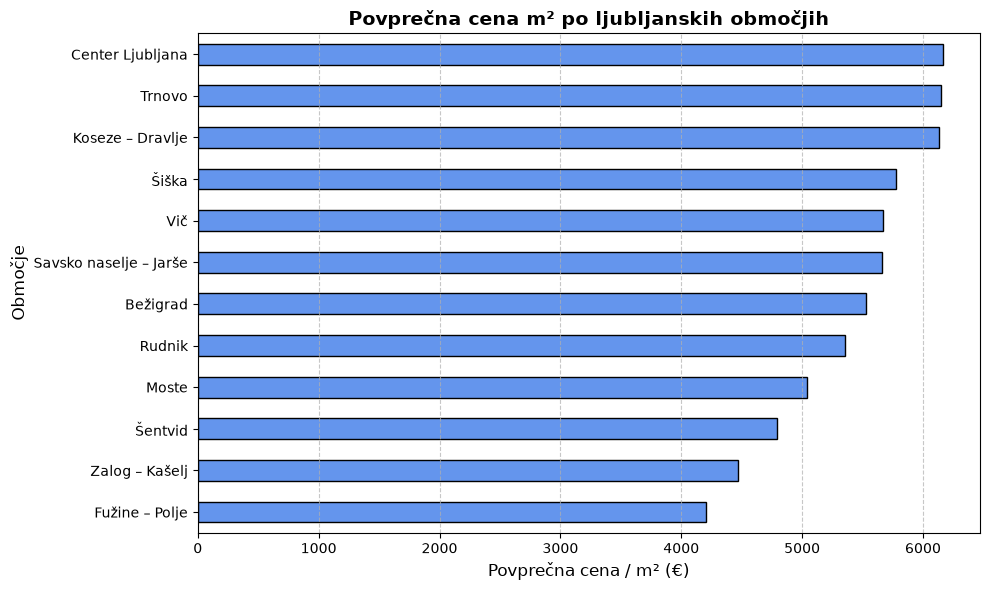

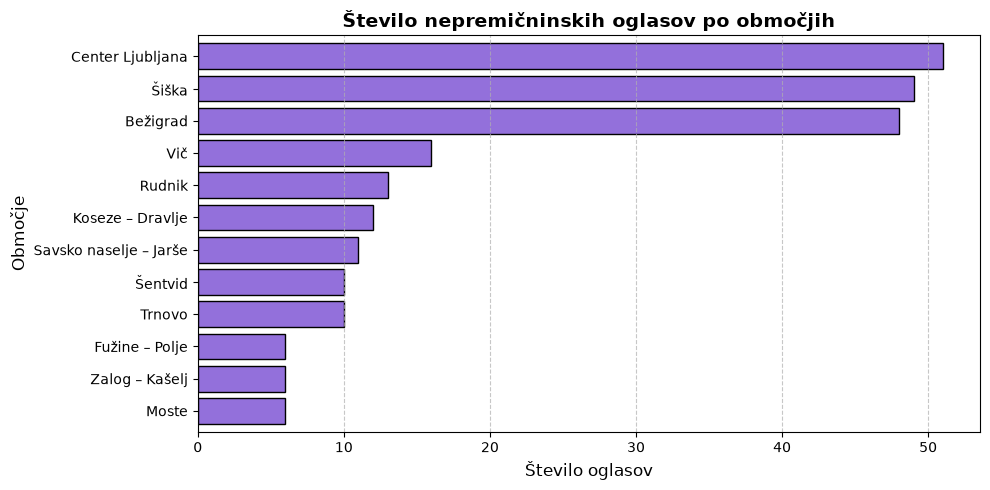

In [ ]:
# 1. GRAF: Povprečna cena m² po območjih (horizontalni stolpci)
plt.figure(figsize=(10, 6))
statistike_urejene['povprečje'].sort_values().plot(kind='barh', color='cornflowerblue', edgecolor='black')
plt.title('Povprečna cena m² po ljubljanskih območjih', fontsize=14, fontweight='bold')
plt.xlabel('Povprečna cena / m² (€)', fontsize=12)
plt.ylabel('Območje', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. GRAF: Število oglasov po območjih
plt.figure(figsize=(10, 5))
df['skupina_lokacij'].value_counts().sort_values().plot(kind='barh', color='mediumpurple', edgecolor='black', width=0.8)
plt.title('Število nepremičninskih oglasov po območjih', fontsize=14, fontweight='bold')
plt.xlabel('Število oglasov', fontsize=12)
plt.ylabel('Območje', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Naprednejša analiza in vpliv lastnosti stanovanj
V zadnjem delu analize preučujemo strukturo stanovanj glede na število sob, razmerje med kvadraturo in skupno ceno stanovanja ter kako leto gradnje stavbe vpliva na ceno kvadratnega metra.

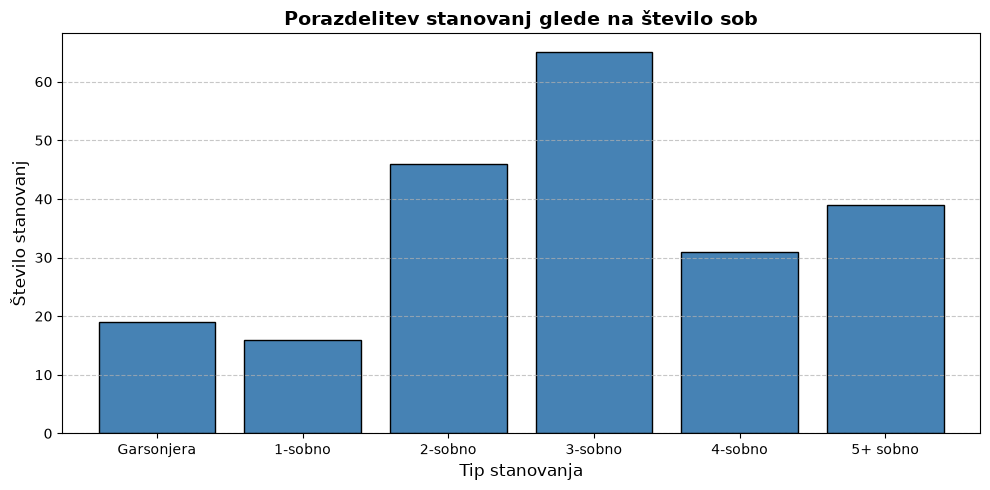

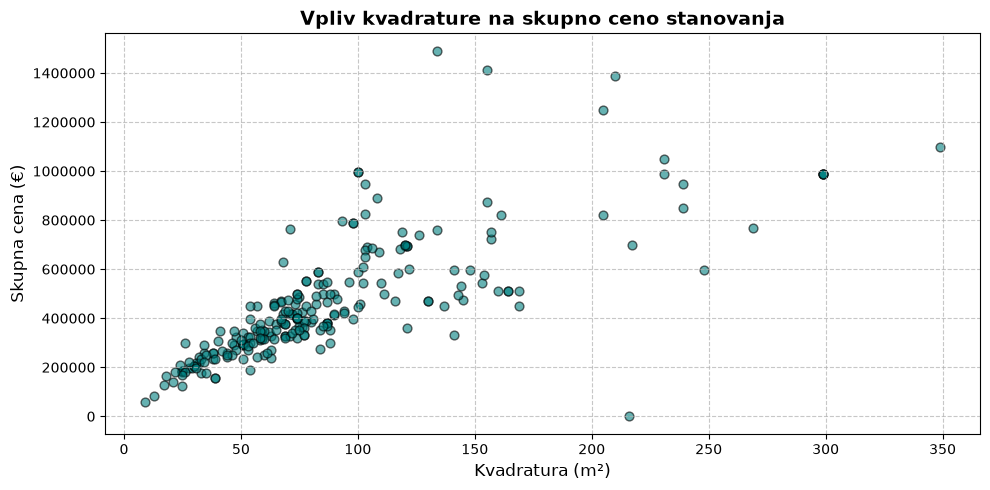

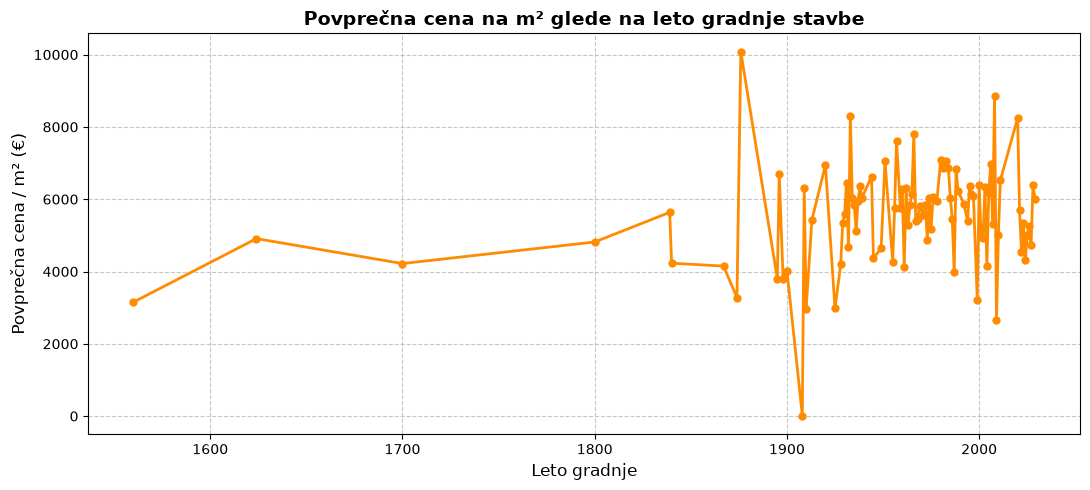

In [ ]:
# 3. GRAF: Porazdelitev stanovanj po številu sob
def ocisti_sobe(val):
    if pd.isna(val):
        return None
    v = str(val).strip().lower()
    if "garsonjer" in v: return "Garsonjera"
    elif "1" in v and "1," not in v and "1." not in v: return "1-sobno"
    elif "2" in v and "2," not in v and "2." not in v: return "2-sobno"
    elif "3" in v and "3," not in v and "3." not in v: return "3-sobno"
    elif "4" in v: return "4-sobno"
    elif "5" in v or "več" in v: return "5+ sobno"
    return None

df['urejene_sobe'] = df['stevilo_sob'].apply(ocisti_sobe)
zeleni_vrstni_red = ["Garsonjera", "1-sobno", "2-sobno", "3-sobno", "4-sobno", "5+ sobno"]
stevci_sob = df['urejene_sobe'].value_counts().reindex([kat for kat in zeleni_vrstni_red if kat in df['urejene_sobe'].unique()])

plt.figure(figsize=(10, 5))
stevci_sob.plot(kind='bar', color='steelblue', edgecolor='black', width=0.8)
plt.title('Porazdelitev stanovanj glede na število sob', fontsize=14, fontweight='bold')
plt.xlabel('Tip stanovanja', fontsize=12)
plt.ylabel('Število stanovanj', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. GRAF: Raztreseni diagram (Kvadratura vs Skupna cena)
plt.figure(figsize=(10, 5))
plt.scatter(df['velikost_num'], df['cena_num'], color='teal', alpha=0.6, edgecolor='black', s=40)
plt.title('Vpliv kvadrature na skupno ceno stanovanja', fontsize=14, fontweight='bold')
plt.xlabel('Kvadratura (m²)', fontsize=12)
plt.ylabel('Skupna cena (€)', fontsize=12)
plt.ticklabel_format(style='plain', axis='both')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 5. GRAF: Povprečna cena na m² glede na leto gradnje
cena_po_letih = df.groupby('leto_num')['cena_per_m2'].mean().sort_index()
plt.figure(figsize=(11, 5))
cena_po_letih.plot(kind='line', marker='o', color='darkorange', linewidth=2, markersize=5)
plt.title('Povprečna cena na m² glede na leto gradnje stavbe', fontsize=14, fontweight='bold')
plt.xlabel('Leto gradnje', fontsize=12)
plt.ylabel('Povprečna cena / m² (€)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Sklep
Iz analize ljubljanskega nepremičninskega trga je razvidno, da so najdražje nepremičnine v ožjem centru in prestižnejših četrtih, medtem ko so obrobna območja cenejša. Prav tako opazimo jasno pozitivno korelacijo med kvadraturo in skupno ceno ter višje cene pri novogradnjah v primerjavi s starejšimi stavbami.